In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- User Configuration Parameters ---
TARGET_DATE = "2026-07-30"  # Format: YYYY-MM-DD
TARGET_ZONE = "DE_LU"

# Base Lakehouse Path
BASE_DIR = Path(
    r"C:\Users\lavee\Desktop\Energy-DataScience-Hari-Om\Projects\day_ahead_forecasting\data\lakehouse"
)


In [22]:
def parse_date_components(date_str: str):
    """Derives year, month, and day strings from an ISO date string."""
    dt = pd.to_datetime(date_str)
    dt_1=dt - pd.Timedelta(days=1)
    return dt.strftime("%Y"), dt.strftime("%m"), dt.strftime("%d"),dt_1
a,b,c,d = parse_date_components("2026-08-01")
d.strftime("%Y")
file_name_1 = f"price_{d.strftime('%Y')}-{d.strftime('%m')}-{d.strftime('%d')}.parquet"
file_name_1



'price_2026-07-31.parquet'

In [42]:
def parse_date_components(date_str: str):
    """Derives year, month, and day strings from an ISO date string."""
    dt = pd.to_datetime(date_str)
    dt_1=dt - pd.Timedelta(days=1)
    return dt,dt_1
def load_forecast_data(base_path: Path, zone: str, target_date: str) -> pd.DataFrame:
    """Loads hourly forecasted prices for the target date."""
    dt, dt_1 = parse_date_components(target_date)
   

    file_name = f"forecast_target={dt.strftime('%Y')}-{dt.strftime('%m')}-{dt.strftime('%d')}.parquet"
    forecast_dir = base_path / "forecasts" / f"zone={zone}" / f"year={dt.strftime('%Y')}" / f"month={dt.strftime('%m')}"/ file_name
    
    file_name_1 = f"price_{dt_1.strftime('%Y')}-{dt_1.strftime('%m')}-{dt_1.strftime('%d')}.parquet" ##file name for actual price of targe day-1
    actual_price_day_1 = base_path / "day_ahead_prices" / f"zone={zone}" / f"year={dt.strftime('%Y')}" / f"month={dt_1.strftime('%m')}"/ file_name_1
    # Check directory or file availability
    
    if not forecast_dir.exists():
        raise FileNotFoundError(f"Forecast directory not found: {forecast_dir}")
    
    # Load directory / parquet files
    df = pd.read_parquet(forecast_dir)
    
    # Ensure hour column exists and filter target date if needed
    if 'date' in df.columns:
        df = df[df['date'] == target_date]

    df["hour"] = df["timestamp"].dt.hour  
    df = df.sort_values("hour").reset_index(drop=True)
    ################actaulprice###########################
    actual_price_df = pd.read_parquet(actual_price_day_1)
    actual_price_df["hour"] = actual_price_df["timestamp"].dt.hour
    actual_price_df = actual_price_df.sort_values("hour").reset_index(drop=True)
    actual_price_df = actual_price_df.set_index("timestamp")
    actual_price_df=actual_price_df.resample("1h").mean(numeric_only=True).reset_index()
    return df, actual_price_df,dt,dt_1

def load_actual_prices(base_path: Path, zone: str, target_date: str) -> pd.DataFrame:
    """Loads actual market clearing prices (P_DA) for the target date."""
    dt, dt_1 = parse_date_components(target_date)
    year = dt.strftime("%Y")
    month = dt.strftime("%m")
    day = dt.strftime("%d")
    day_1 = dt_1.strftime("%d")
    file_name = f"price_{year}-{month}-{day}.parquet"
    price_file = base_path / "day_ahead_prices" / f"zone={zone}" / f"year={year}" / f"month={month}" / file_name
    
    if not price_file.exists():
        raise FileNotFoundError(f"Actual price file not found: {price_file}")
        
    df = pd.read_parquet(price_file)
    df["hour"] = df["timestamp"].dt.hour
    df = df.sort_values("hour").reset_index(drop=True)
    df_hourly = df.set_index("timestamp")

# 2. Auf 1 Stunde resamplen und den Mittelwert berechnen
    df_hourly = df_hourly.resample("1h").mean(numeric_only=True).reset_index()
    return df_hourly

In [4]:
# bids_input = [
#     {"hour": 9,  "side": "BUY",  "limit_price": 110.0, "volume_mw": 10.0},
#     {"hour": 10,  "side": "BUY",  "limit_price": 110.0, "volume_mw": 15.0},
#     {"hour": 11, "side": "BUY", "limit_price": 110.0, "volume_mw": 20.0},
#     {"hour": 12, "side": "BUY", "limit_price": 110.0, "volume_mw": 12.0},
#     {"hour": 13, "side": "BUY",  "limit_price": 110.0, "volume_mw": 8.0},
# ]

bids_df = pd.read_excel("Bids.xlsx")
print("--- User Submitted Limit Bids ---")
display(bids_df)

--- User Submitted Limit Bids ---


,hour,side,limit_price,volume_mw
0,8,BUY,110,10
1,9,BUY,110,10
2,10,BUY,110,10
3,11,BUY,110,15
4,12,BUY,110,20
5,13,BUY,110,20
6,14,BUY,110,25
7,18,SELL,170,10
8,19,SELL,170,10
9,20,SELL,170,20


In [5]:
def plot_forecast_and_bids(forecast_df: pd.DataFrame, bids_df: pd.DataFrame, target_date: str):
    plt.figure(figsize=(12, 6))
    
    # Forecast Price Line Plot
    plt.plot(
        forecast_df['hour'], 
        forecast_df['forecast_price_eur_mwh'], 
        label='Forecast Price ($P_{forecast}$)', 
        color='#1f77b4', 
        linewidth=2, 
        linestyle='--'
    )
    
    # Overlay Limit Bids
    if not bids_df.empty:
        buys = bids_df[bids_df['side'] == 'BUY']
        sells = bids_df[bids_df['side'] == 'SELL']
        
        plt.scatter(
            buys['hour'], buys['limit_price'], 
            color='green', marker='^', s=120, zorder=5, label='BUY Limit Bid'
        )
        plt.scatter(
            sells['hour'], sells['limit_price'], 
            color='red', marker='v', s=120, zorder=5, label='SELL Limit Offer'
        )
        
        # Add labels near markers
        for _, row in bids_df.iterrows():
            plt.annotate(
                f"{row['side']} @ {row['limit_price']}€ ({row['volume_mw']}MW)",
                (row['hour'], row['limit_price']),
                textcoords="offset points", 
                xytext=(0, 10 if row['side']=='BUY' else -15),
                ha='center', fontsize=8, fontweight='bold'
            )
            
    plt.title(f"Day-Ahead Forecast & Limit Bids | Date: {target_date} | Zone: {TARGET_ZONE}", fontsize=14)
    plt.xlabel("Hour of Day (0 - 23)", fontsize=11)
    plt.ylabel("Price (€/MWh)", fontsize=11)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [6]:
def evaluate_market_clearing(
    forecast_df: pd.DataFrame, 
    actual_df: pd.DataFrame, 
    bids_df: pd.DataFrame
) -> pd.DataFrame:
    """Evaluates bids against Day-Ahead market clearing prices."""
    
    # Base 24-Hour Frame
    ledger = pd.DataFrame({'hour': range(24)})
    
    # Merge forecast and actual price data
    ledger = ledger.merge(forecast_df[['hour', 'forecast_price_eur_mwh']], on='hour', how='left')
    ledger = ledger.merge(actual_df[['hour', 'price_eur_mwh']], on='hour', how='left')
    
    # Merge User Bids
    ledger = ledger.merge(bids_df, on='hour', how='left')
    
    # Execution Logic
    cleared_list = []
    cleared_mw_list = []
    cashflow_list = []
    position_list = []
    
    for _, row in ledger.iterrows():
        side = row['side']
        limit_price = row['limit_price']
        volume = row['volume_mw']
        p_da = row['price_eur_mwh']
        
        if pd.isna(side):
            cleared_list.append("NO BID")
            cleared_mw_list.append(0.0)
            cashflow_list.append(0.0)
            position_list.append("FLAT")
            continue
            
        # BUY Bid Logic: Clears if P_DA <= Limit Price
        if side == "BUY":
            if p_da <= limit_price:
                cleared_list.append("CLEARED")
                cleared_mw = volume
                # Buying energy -> Cash Outflow
                cashflow = -1.0 * volume * p_da
                pos = "LONG"
            else:
                cleared_list.append("REJECTED")
                cleared_mw = 0.0
                cashflow = 0.0
                pos = "FLAT"
                
        # SELL Bid Logic: Clears if P_DA >= Limit Price
        elif side == "SELL":
            if p_da >= limit_price:
                cleared_list.append("CLEARED")
                cleared_mw = -volume
                # Selling energy -> Cash Inflow
                cashflow = 1.0 * volume * p_da
                pos = "SHORT"
            else:
                cleared_list.append("REJECTED")
                cleared_mw = 0.0
                cashflow = 0.0
                pos = "FLAT"
                
        cleared_list.append(cleared_list.pop()) # Keep synced
        cleared_mw_list.append(cleared_mw)
        cashflow_list.append(cashflow)
        position_list.append(pos)
        
    ledger['Cleared'] = cleared_list
    ledger['Cleared_MW'] = cleared_mw_list
    ledger['Cashflow_€'] = cashflow_list
    ledger['Position_Status'] = position_list
    
    return ledger

In [66]:
# TARGET_DATE = "2026-07-31"
# TARGET_ZONE = "DE_LU"
# --- Step Execution ---
def run_day_ahead_pnl_analysis(base_dir: Path, target_zone: str, target_date: str):
    try:
        # 1. Load Data from Lakehouse
        

        forecast_df, actual_price_yesterday, dt, dt_1 = load_forecast_data(BASE_DIR, TARGET_ZONE, TARGET_DATE)
        # print(f"Forecasted Day-Ahead Prices of{dt.strftime('%Y-%m-%d')}")
        # print(forecast_df["forecast_price_eur_mwh"])

        # input("Press Enter to show Actual Prices...")
        # print(f"--- Actual Prices from Yesterday ({dt_1.strftime('%Y-%m-%d')}) ---")
        # print(actual_price_yesterday["price_eur_mwh"])
        
        summary = pd.DataFrame({'hour': range(24)})

        forecast_col = f"forecast_{dt.strftime('%Y-%m-%d')}"
        actual_col = f"actual_{dt_1.strftime('%Y-%m-%d')}"

        summary = summary.merge(forecast_df[['hour', 'forecast_price_eur_mwh']].rename(columns={'forecast_price_eur_mwh': forecast_col}), on='hour', how='left')
        summary = summary.merge(actual_price_yesterday[['hour', 'price_eur_mwh']].rename(columns={'price_eur_mwh': actual_col}), on='hour', how='left')
        
        print(summary)

        input("Enter your bids in Excel sheet and press Enter to continue...")
        bids_df = pd.read_excel("Bids.xlsx")
        print("--- User Submitted Limit Bids ---")
        actual_df = load_actual_prices(BASE_DIR, TARGET_ZONE, TARGET_DATE)
    except FileNotFoundError:
        print("⚠️ Path not found. Using simulated data for testing dashboard visualization...")
        # forecast_df, actual_df = mock_lakehouse_data()

    # 2. Plot Forecast & Overlaid Bids
    plot_forecast_and_bids(forecast_df, bids_df, TARGET_DATE)

    # 3. Calculate Ledger & Settlement
    ledger_df = evaluate_market_clearing(forecast_df, actual_df, bids_df)

    # 4. Compute High-Level Metrics
    total_bids = len(bids_df)
    cleared_bids = len(ledger_df[ledger_df['Cleared'] == 'CLEARED'])
    clearance_rate = (cleared_bids / total_bids * 100) if total_bids > 0 else 0.0

    total_cashflow = ledger_df['Cashflow_€'].sum()
    net_position_mw = ledger_df['Cleared_MW'].sum()

    # 5. Output 24-Hour Day-Ahead Ledger Table
    print("\n" + "="*80)
    print(f"📊 DAY-AHEAD TRADING LEDGER ({TARGET_DATE})")
    print("="*80)

    display_columns = [
        'hour', 'forecast_price_eur_mwh', 'price_eur_mwh', 'side', 'limit_price', 
        'volume_mw', 'Cleared', 'Cleared_MW', 'Position_Status', 'Cashflow_€'
    ]

    display(ledger_df[display_columns].fillna('-'))

    # 6. Output Summary Metrics Dashboard
    print("-" * 50)
    print("📈 SUMMARY METRICS DASHBOARD")
    print("-" * 50)
    print(f"Total Submitted Bids : {total_bids}")
    print(f"Cleared Bids         : {cleared_bids}")
    print(f"Order Clearance Rate : {clearance_rate:.2f}%")
    print(f"Net Open Position    : {net_position_mw:+.2f} MW")
    print(f"Net Cashflow         : €{total_cashflow:+,.2f}")
    print("-" * 50)
    return ledger_df

In [67]:
# TARGET_DATE = "2026-07-31"
# TARGET_ZONE = "DE_LU"
# ledger_df=run_day_ahead_pnl_analysis(BASE_DIR, TARGET_ZONE, TARGET_DATE)


    hour  forecast_2026-08-01  actual_2026-07-31
0      0           154.359104           155.1600
1      1           150.763738           154.1725
2      2           133.858902           157.3400
3      3           147.235264           165.5125
4      4           159.738384           179.0875
5      5           147.855296           172.5275
6      6           144.365745           159.0775
7      7           138.126550           139.3875
8      8           106.394317           119.6050
9      9            70.709724           101.1700
10    10            39.288888            94.1175
11    11            13.653261            83.2675
12    12            11.653445            86.2850
13    13            17.668962           103.1350
14    14            43.560963           120.8650
15    15            87.798671           147.4925
16    16           131.247714           162.3075
17    17           163.392461           184.8850
18    18           184.935274           192.7400
19    19           1

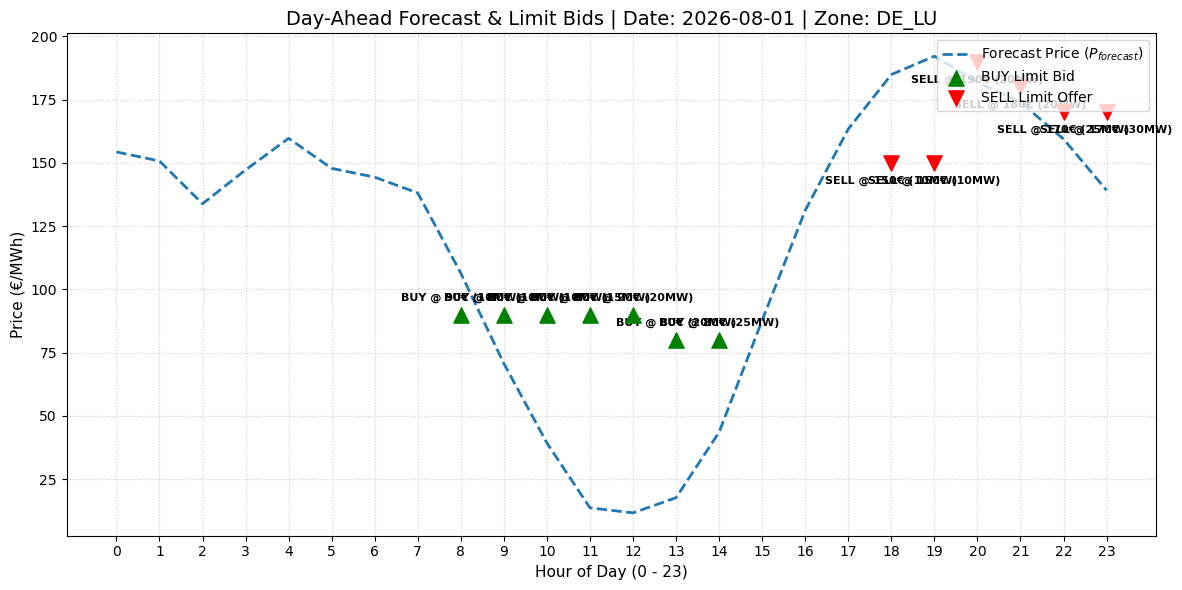


📊 DAY-AHEAD TRADING LEDGER (2026-08-01)


,hour,forecast_price_eur_mwh,price_eur_mwh,side,limit_price,volume_mw,Cleared,Cleared_MW,Position_Status,Cashflow_€
0,0,154.359104,156.9950,-,-,-,NO BID,0.0,FLAT,0.0000
1,1,150.763738,154.6075,-,-,-,NO BID,0.0,FLAT,0.0000
2,2,133.858902,154.5225,-,-,-,NO BID,0.0,FLAT,0.0000
3,3,147.235264,155.5175,-,-,-,NO BID,0.0,FLAT,0.0000
4,4,159.738384,154.7900,-,-,-,NO BID,0.0,FLAT,0.0000
5,5,147.855296,146.4225,-,-,-,NO BID,0.0,FLAT,0.0000
6,6,144.365745,140.4075,-,-,-,NO BID,0.0,FLAT,0.0000
7,7,138.126550,123.2725,-,-,-,NO BID,0.0,FLAT,0.0000
8,8,106.394317,100.9225,BUY,90.0,10.0,REJECTED,0.0,FLAT,0.0000
9,9,70.709724,57.1525,BUY,90.0,10.0,CLEARED,10.0,LONG,-571.5250


--------------------------------------------------
📈 SUMMARY METRICS DASHBOARD
--------------------------------------------------
Total Submitted Bids : 13
Cleared Bids         : 8
Order Clearance Rate : 61.54%
Net Open Position    : +80.00 MW
Net Cashflow         : €+1,672.12
--------------------------------------------------


In [70]:
TARGET_DATE = "2026-08-01"
TARGET_ZONE = "DE_LU"
ledger_df=run_day_ahead_pnl_analysis(BASE_DIR, TARGET_ZONE, TARGET_DATE)


'price_2026-07-31.parquet'

In [32]:
b

WindowsPath('C:/Users/lavee/Desktop/Energy-DataScience-Hari-Om/Projects/day_ahead_forecasting/data/lakehouse/day_ahead_prices/zone=DE_LU/year=2026/month=08/price_2026-07-31.parquet')